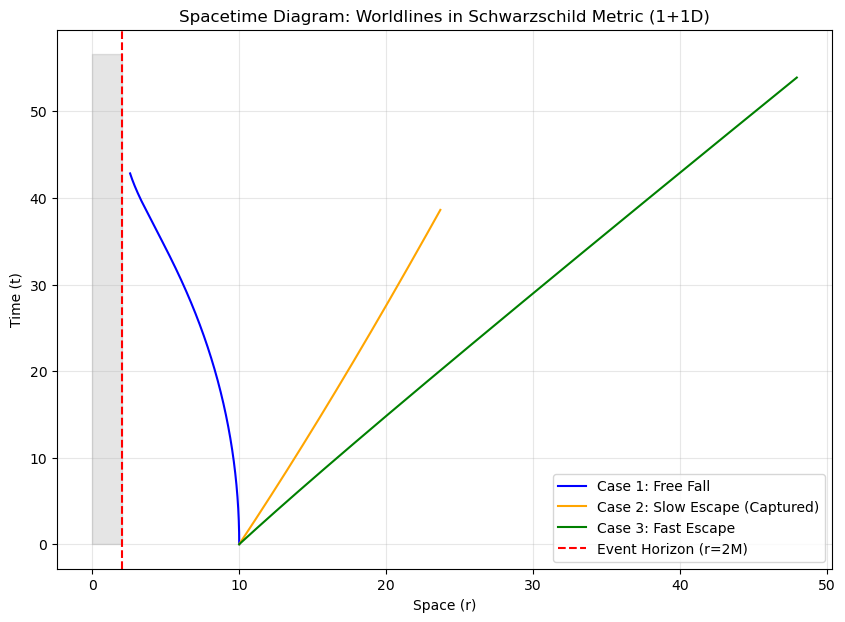

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 定数設定 (G = c = 1 の幾何学単位系)
M = 1.0  # 重力源の質量
Rs = 2 * M  # シュヴァルツシルト半径（イベントホライゾン）

def geodesic_equations(y, tau, M):
    """
    測地線方程式を定義する関数
    y = [t, r, dt/dtau, dr/dtau]
    """
    t, r, dt, dr = y
    
    # 2階微分を計算
    # d2t/dtau^2
    d2t = -(2 * M / (r * (r - 2 * M))) * dt * dr
    
    # d2r/dtau^2
    d2r = -(M * (r - 2 * M) / r**3) * dt**2 + (M / (r * (r - 2 * M))) * dr**2
    
    return [dt, dr, d2t, d2r]

def simulate_particle(r0, dr0, tau_max, num_steps=1000):
    tau = np.linspace(0, tau_max, num_steps)
    
    # 計量条件から初期の dt/dtau を計算 (固有時間の定義: ds^2 = -dtau^2)
    # - (1 - 2M/r)dt^2 + (1 - 2M/r)^-1 dr^2 = -dtau^2
    # dt = sqrt( (1 + (1-2M/r)^-1 * dr^2) / (1-2M/r) )
    term1 = 1 / (1 - 2*M/r0)
    dt0 = np.sqrt((1 + term1 * dr0**2) / (1 - 2*M/r0))
    
    y0 = [0, r0, dt0, dr0]
    sol = odeint(geodesic_equations, y0, tau, args=(M,))
    return sol

# シミュレーションの実行
tau_limit = 33
# 1. 自由落下 (初速なし)
sol1 = simulate_particle(r0=10.0, dr0=0.0, tau_max=tau_limit)
# 2. 脱出を試みるが捕まる (外向き初速 小)
sol2 = simulate_particle(r0=10.0, dr0=0.5, tau_max=tau_limit)
# 3. 脱出成功 (外向き初速 大)
sol3 = simulate_particle(r0=10.0, dr0=1.2, tau_max=tau_limit)

# 可視化
plt.figure(figsize=(10, 7))
plt.plot(sol1[:, 1], sol1[:, 0], label="Case 1: Free Fall", color='blue')
plt.plot(sol2[:, 1], sol2[:, 0], label="Case 2: Slow Escape (Captured)", color='orange')
plt.plot(sol3[:, 1], sol3[:, 0], label="Case 3: Fast Escape", color='green')

# イベントホライゾンを表示
plt.axvline(x=Rs, color='red', linestyle='--', label="Event Horizon (r=2M)")
plt.fill_betweenx([0, plt.ylim()[1]], 0, Rs, color='black', alpha=0.1)

plt.xlabel("Space (r)")
plt.ylabel("Time (t)")
plt.title("Spacetime Diagram: Worldlines in Schwarzschild Metric (1+1D)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

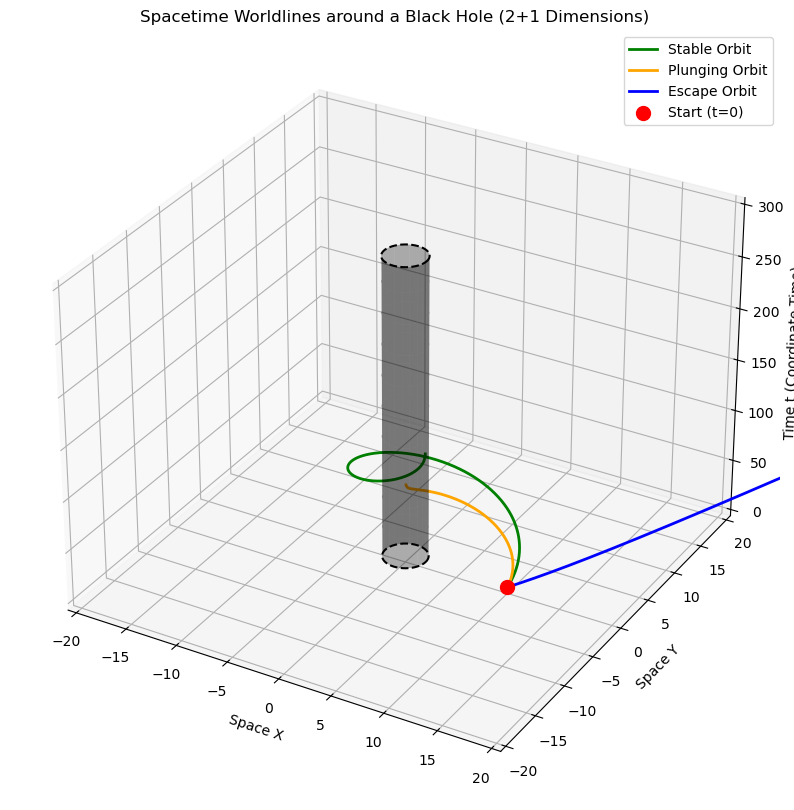

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# --- 定数設定 (G = c = 1) ---
M = 1.0
Rs = 2 * M

# --- 測地線方程式 (前回と同じ) ---
def geodesic_equations_2d(y, tau, M):
    t, r, phi, dt, dr, dphi = y
    if r <= 2.01 * M: return [0, 0, 0, 0, 0, 0] # 安全策
    term_r_minus_2m = r - 2 * M
    d2t = -(2 * M / (r * term_r_minus_2m)) * dt * dr
    d2r = - (M * term_r_minus_2m / r**3) * dt**2 \
          + (M / (r * term_r_minus_2m)) * dr**2 \
          + term_r_minus_2m * dphi**2
    d2phi = -(2.0 / r) * dr * dphi
    return [dt, dr, dphi, d2t, d2r, d2phi]

# --- シミュレーション実行関数 (前回と同じ) ---
def simulate_orbit(r0, phi0, v_r0, v_phi0, tau_max, num_steps=5000):
    tau = np.linspace(0, tau_max, num_steps)
    dr0 = v_r0
    dphi0 = v_phi0
    g_tt_inv = 1.0 / (1 - 2*M/r0)
    metric_val = g_tt_inv * dr0**2 + r0**2 * dphi0**2
    dt0 = np.sqrt((1 + metric_val) * g_tt_inv)
    y0 = [0, r0, phi0, dt0, dr0, dphi0]
    sol = odeint(geodesic_equations_2d, y0, tau, args=(M,), rtol=1e-9, atol=1e-9)
    return sol

# --- メイン処理：シミュレーション実行 (前回と同じ設定) ---
tau_end = 250
# Case 1: 安定した周回 (緑)
sol1 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.0, v_phi0=0.033, tau_max=tau_end)
# Case 2: 落下する軌道 (オレンジ)
sol2 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.0, v_phi0=0.02, tau_max=tau_end)
# Case 3: 脱出する軌道 (青)
sol3 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.5, v_phi0=0.05, tau_max=tau_end)


# --- 新規：3D時空図の可視化 ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# データを直交座標(x, y)と時間(t)に変換する関数
def get_spacetime_coords(sol, max_t_display=300):
    t_coord = sol[:, 0]
    r = sol[:, 1]
    phi = sol[:, 2]
    
    # イベントホライゾンごく近傍のデータを除去（描画の乱れを防ぐ）
    # また、落下軌道ではtが無限大に発散するため、表示上の上限を設ける
    mask = (r > Rs * 1.01) & (t_coord < max_t_display)
    
    t_clean = t_coord[mask]
    x_clean = r[mask] * np.cos(phi[mask])
    y_clean = r[mask] * np.sin(phi[mask])
    
    # 3Dプロットでは (横, 奥行き, 高さ) = (x, y, t) とする
    return x_clean, y_clean, t_clean

# 各軌道の座標を取得
x1, y1, t1 = get_spacetime_coords(sol1)
x2, y2, t2 = get_spacetime_coords(sol2)
x3, y3, t3 = get_spacetime_coords(sol3)

# 軌道（世界線）のプロット
# Z軸を時間 t に設定します
ax.plot(x1, y1, t1, color='green', label='Stable Orbit', linewidth=2)
ax.plot(x2, y2, t2, color='orange', label='Plunging Orbit', linewidth=2)
ax.plot(x3, y3, t3, color='blue', label='Escape Orbit', linewidth=2)

# スタート地点の表示 (t=0平面上)
ax.scatter(10, 0, 0, color='red', s=100, label="Start (t=0)", zorder=10)


# イベントホライゾンを「円柱」として描画 (時間方向に伸びるため)
theta_cyl = np.linspace(0, 2*np.pi, 50)
t_cyl_vals = np.linspace(0, max(t1.max(), t3.max()), 50) # 時間方向の範囲
theta_grid, t_grid = np.meshgrid(theta_cyl, t_cyl_vals)
x_cyl = Rs * np.cos(theta_grid)
y_cyl = Rs * np.sin(theta_grid)
z_cyl = t_grid # 高さを時間とする

ax.plot_surface(x_cyl, y_cyl, z_cyl, color='black', alpha=0.3, rstride=5, cstride=5)
# ホライゾンの底面と上面の縁を描く
ax.plot(Rs*np.cos(theta_cyl), Rs*np.sin(theta_cyl), 0, color='black', linestyle='--')
ax.plot(Rs*np.cos(theta_cyl), Rs*np.sin(theta_cyl), t_cyl_vals.max(), color='black', linestyle='--')


# グラフの見た目を調整
ax.set_xlabel('Space X')
ax.set_ylabel('Space Y')
ax.set_zlabel('Time t (Coordinate Time)')
ax.set_title('Spacetime Worldlines around a Black Hole (2+1 Dimensions)')

# 視点の調整 (上から見下ろしつつ、時間の経過がわかる角度)
ax.view_init(elev=30, azim=-60)

ax.set_xlim(-20, 20)
ax.set_ylim(-20, 20)
ax.set_zlim(0, 300) # 時間軸の表示範囲

plt.legend()
plt.show()

In [3]:
# https://gemini.google.com/share/a15ec7294bd8

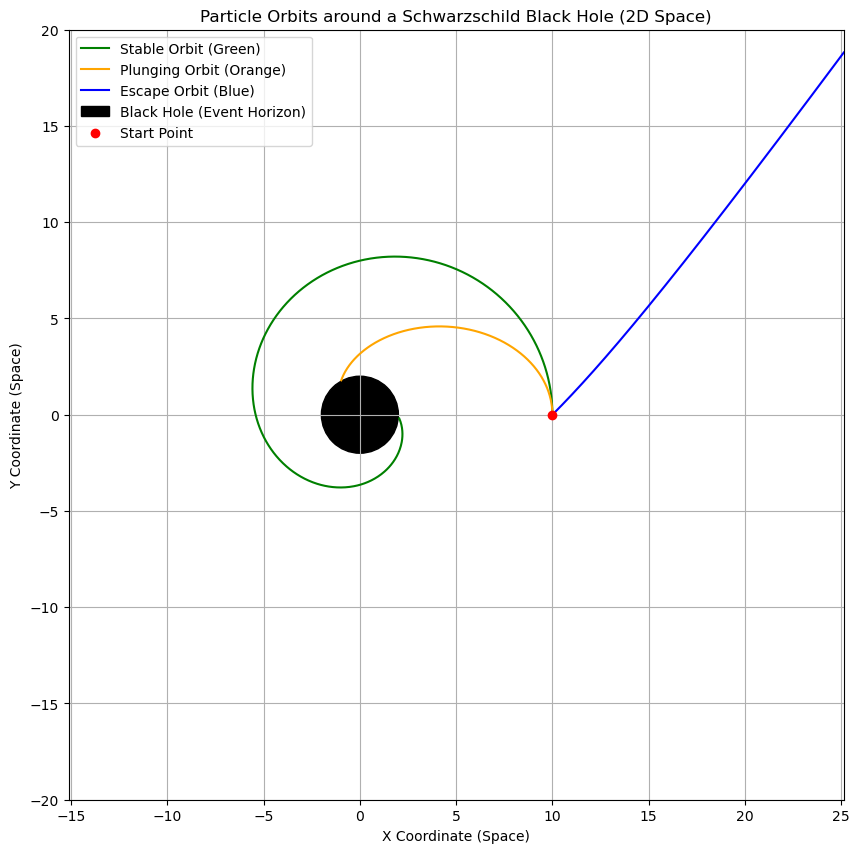

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- 定数設定 (G = c = 1) ---
M = 1.0       # 重力源の質量
Rs = 2 * M    # イベントホライゾン半径

# --- 測地線方程式 (空間2次元 + 時間1次元) ---
def geodesic_equations_2d(y, tau, M):
    """
    状態ベクトル y = [t, r, phi, dt/dtau, dr/dtau, dphi/dtau]
    """
    t, r, phi, dt, dr, dphi = y
    
    # r=2Mでのゼロ割りを防ぐための安全策（計算上の発散回避）
    if r <= 2.01 * M:
        return [0, 0, 0, 0, 0, 0]

    # 共通項
    term_r_minus_2m = r - 2 * M
    term_inv_r_minus_2m = 1.0 / term_r_minus_2m

    # 2階微分 (加速度成分) の計算
    # d2t / dtau^2
    d2t = -(2 * M / (r * term_r_minus_2m)) * dt * dr
    
    # d2r / dtau^2
    # 一般相対論的な有効ポテンシャルの微分から導かれる項
    # 遠心力項に相対論的補正 (r-2M) がかかっている点に注意
    d2r = - (M * term_r_minus_2m / r**3) * dt**2 \
          + (M / (r * term_r_minus_2m)) * dr**2 \
          + term_r_minus_2m * dphi**2

    # d2phi / dtau^2 (角運動量保存に対応)
    d2phi = -(2.0 / r) * dr * dphi
    
    return [dt, dr, dphi, d2t, d2r, d2phi]

# --- シミュレーション実行関数 ---
def simulate_orbit(r0, phi0, v_r0, v_phi0, tau_max, num_steps=5000):
    """
    r0, phi0: 初期位置
    v_r0: 初期の動径方向速度 (dr/dtau)
    v_phi0: 初期の角速度 (dphi/dtau)
    """
    tau = np.linspace(0, tau_max, num_steps)
    
    # 初期条件の設定と計量条件からの dt/dtau の計算
    dr0 = v_r0
    dphi0 = v_phi0
    
    # 計量条件: -1 = g_tt*dt^2 + g_rr*dr^2 + g_phiphi*dphi^2
    # -1 = -(1-2M/r)dt^2 + (1-2M/r)^-1 dr^2 + r^2 dphi^2
    # これを dt について解く
    g_tt_inv = 1.0 / (1 - 2*M/r0)
    metric_val = g_tt_inv * dr0**2 + r0**2 * dphi0**2
    dt0 = np.sqrt((1 + metric_val) * g_tt_inv)
    
    y0 = [0, r0, phi0, dt0, dr0, dphi0]
    
    # 微分方程式を解く
    sol = odeint(geodesic_equations_2d, y0, tau, args=(M,), rtol=1e-9, atol=1e-9)
    return sol

# --- メイン処理 ---

# 3つのケースをシミュレーション
tau_end = 250

# Case 1: 安定した周回軌道 (十分な角速度を与える)
# r=10での円軌道に近い速度を設定
sol1 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.0, v_phi0=0.033, tau_max=tau_end)

# Case 2: 落下する軌道 (角速度が足りない)
sol2 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.0, v_phi0=0.02, tau_max=tau_end)

# Case 3: 脱出する軌道 (初速が大きい)
# 外向きの速度を与える
sol3 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.5, v_phi0=0.05, tau_max=tau_end)


# --- 可視化 (空間軌道プロット) ---
plt.figure(figsize=(10, 10))

# 極座標から直交座標へ変換
def to_cartesian(sol):
    r = sol[:, 1]
    phi = sol[:, 2]
    # r < 2M に突入したデータ点はプロットから除外（描画上の都合）
    mask = r > Rs * 1.01
    x = r[mask] * np.cos(phi[mask])
    y = r[mask] * np.sin(phi[mask])
    return x, y

x1, y1 = to_cartesian(sol1)
x2, y2 = to_cartesian(sol2)
x3, y3 = to_cartesian(sol3)

# 軌道のプロット
plt.plot(x1, y1, label='Stable Orbit (Green)', color='green', linewidth=1.5)
plt.plot(x2, y2, label='Plunging Orbit (Orange)', color='orange', linewidth=1.5)
plt.plot(x3, y3, label='Escape Orbit (Blue)', color='blue', linewidth=1.5)

# 中心星とイベントホライゾンの描画
circle_bh = plt.Circle((0, 0), Rs, color='black', label='Black Hole (Event Horizon)')
plt.gca().add_patch(circle_bh)
# スターティングポイント
plt.scatter(10, 0, color='red', zorder=5, label="Start Point")

# グラフの設定
plt.xlabel('X Coordinate (Space)')
plt.ylabel('Y Coordinate (Space)')
plt.title('Particle Orbits around a Schwarzschild Black Hole (2D Space)')
plt.grid(True)
plt.axis('equal') # 縦横比を合わせる
plt.xlim(-15, 25)
plt.ylim(-20, 20)
plt.legend()
plt.show()

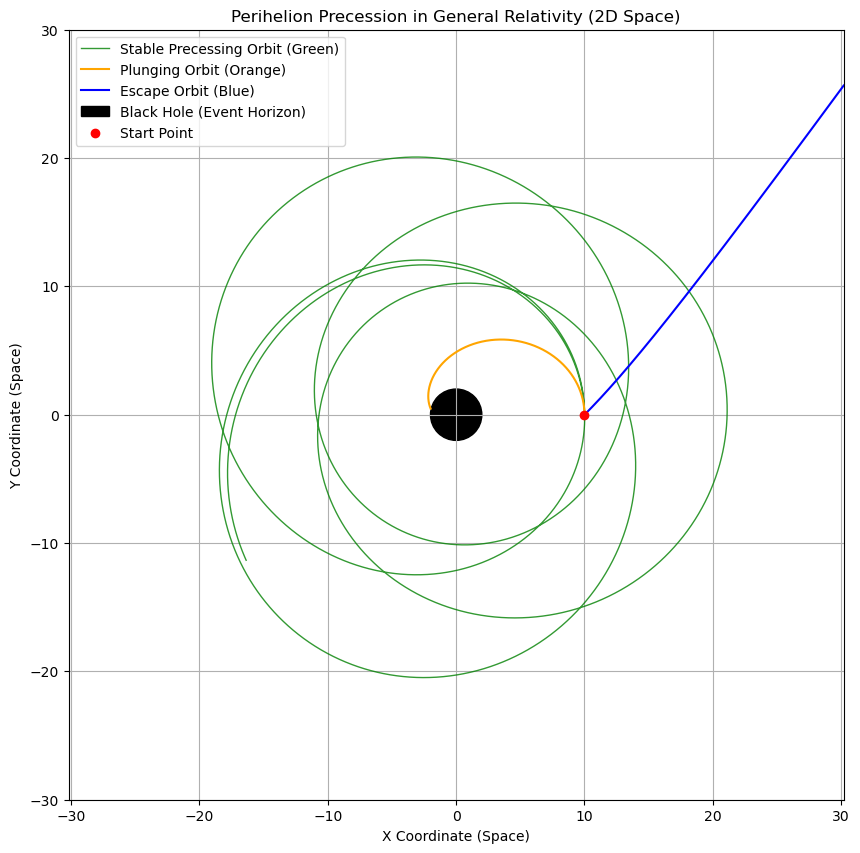

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- 定数設定 (G = c = 1) ---
M = 1.0       # 重力源の質量
Rs = 2 * M    # イベントホライゾン半径

# --- 測地線方程式 (空間2次元 + 時間1次元) ---
# ※前回と同じ関数です
def geodesic_equations_2d(y, tau, M):
    t, r, phi, dt, dr, dphi = y
    if r <= 2.01 * M: return [0, 0, 0, 0, 0, 0]
    term_r_minus_2m = r - 2 * M
    d2t = -(2 * M / (r * term_r_minus_2m)) * dt * dr
    d2r = - (M * term_r_minus_2m / r**3) * dt**2 \
          + (M / (r * term_r_minus_2m)) * dr**2 \
          + term_r_minus_2m * dphi**2
    d2phi = -(2.0 / r) * dr * dphi
    return [dt, dr, dphi, d2t, d2r, d2phi]

# --- シミュレーション実行関数 ---
# ※前回と同じ関数です
def simulate_orbit(r0, phi0, v_r0, v_phi0, tau_max, num_steps=10000): # ステップ数を増加
    tau = np.linspace(0, tau_max, num_steps)
    dr0 = v_r0
    dphi0 = v_phi0
    g_tt_inv = 1.0 / (1 - 2*M/r0)
    metric_val = g_tt_inv * dr0**2 + r0**2 * dphi0**2
    dt0 = np.sqrt((1 + metric_val) * g_tt_inv)
    y0 = [0, r0, phi0, dt0, dr0, dphi0]
    sol = odeint(geodesic_equations_2d, y0, tau, args=(M,), rtol=1e-9, atol=1e-9)
    return sol

# --- メイン処理：パラメータを修正 ---

# 【修正点1】計算時間を大幅に延長 (250 -> 1500)
tau_end = 1500

# Case 1: 安定した周回軌道 (緑)
# 【修正点2】初期角速度 v_phi0 を増加 (0.033 -> 0.042)
# これにより、落下せずに楕円軌道を描いて回り続けます。
sol1 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.0, v_phi0=0.042, tau_max=tau_end)

# Case 2: 落下する軌道 (オレンジ) - 比較用そのままでOKですが、時間延長で見え方を調整
sol2 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.0, v_phi0=0.025, tau_max=300)

# Case 3: 脱出する軌道 (青) - 比較用そのまま
sol3 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.5, v_phi0=0.05, tau_max=300)


# --- 可視化 (空間軌道プロット) ---
plt.figure(figsize=(10, 10))

def to_cartesian(sol):
    r = sol[:, 1]
    phi = sol[:, 2]
    mask = r > Rs * 1.01
    x = r[mask] * np.cos(phi[mask])
    y = r[mask] * np.sin(phi[mask])
    return x, y

x1, y1 = to_cartesian(sol1)
x2, y2 = to_cartesian(sol2)
x3, y3 = to_cartesian(sol3)

# 軌道のプロット
# 緑の軌道は細くして、重なりを見やすくする
plt.plot(x1, y1, label='Stable Precessing Orbit (Green)', color='green', linewidth=1.0, alpha=0.8)
plt.plot(x2, y2, label='Plunging Orbit (Orange)', color='orange', linewidth=1.5)
plt.plot(x3, y3, label='Escape Orbit (Blue)', color='blue', linewidth=1.5)

# 中心星とイベントホライゾンの描画
circle_bh = plt.Circle((0, 0), Rs, color='black', label='Black Hole (Event Horizon)')
plt.gca().add_patch(circle_bh)
# スターティングポイント
plt.scatter(10, 0, color='red', zorder=5, label="Start Point")

# グラフの設定
plt.xlabel('X Coordinate (Space)')
plt.ylabel('Y Coordinate (Space)')
plt.title('Perihelion Precession in General Relativity (2D Space)')
plt.grid(True)
plt.axis('equal')
plt.xlim(-30, 30)
plt.ylim(-30, 30)
plt.legend()
plt.show()

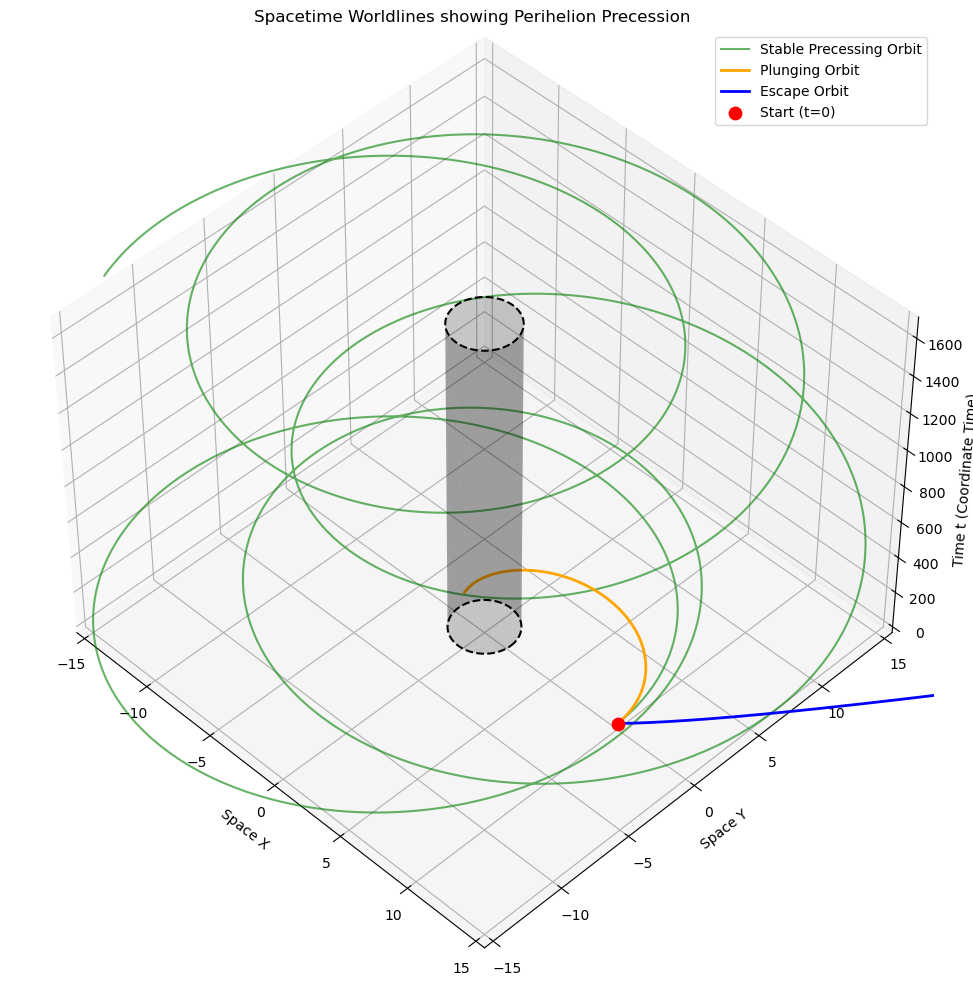

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from mpl_toolkits.mplot3d import Axes3D

# --- 定数設定 (G = c = 1) ---
M = 1.0
Rs = 2 * M

# --- 測地線方程式 ---
def geodesic_equations_2d(y, tau, M):
    t, r, phi, dt, dr, dphi = y
    if r <= 2.01 * M: return [0, 0, 0, 0, 0, 0]
    term_r_minus_2m = r - 2 * M
    d2t = -(2 * M / (r * term_r_minus_2m)) * dt * dr
    d2r = - (M * term_r_minus_2m / r**3) * dt**2 \
          + (M / (r * term_r_minus_2m)) * dr**2 \
          + term_r_minus_2m * dphi**2
    d2phi = -(2.0 / r) * dr * dphi
    return [dt, dr, dphi, d2t, d2r, d2phi]

# --- シミュレーション実行関数 ---
# ステップ数を増やして精度を確保
def simulate_orbit(r0, phi0, v_r0, v_phi0, tau_max, num_steps=20000):
    tau = np.linspace(0, tau_max, num_steps)
    dr0 = v_r0
    dphi0 = v_phi0
    g_tt_inv = 1.0 / (1 - 2*M/r0)
    metric_val = g_tt_inv * dr0**2 + r0**2 * dphi0**2
    dt0 = np.sqrt((1 + metric_val) * g_tt_inv)
    y0 = [0, r0, phi0, dt0, dr0, dphi0]
    sol = odeint(geodesic_equations_2d, y0, tau, args=(M,), rtol=1e-10, atol=1e-10)
    return sol

# --- メイン処理：修正されたパラメータで実行 ---

# Case 1: 安定した周回軌道 (緑) - 長時間シミュレーション
# v_phi0 = 0.042, tau_max = 1500
sol1 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.0, v_phi0=0.042, tau_max=1500)

# Case 2: 落下する軌道 (オレンジ) - 比較用短時間
# v_phi0 = 0.025, tau_max = 300
sol2 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.0, v_phi0=0.025, tau_max=300)

# Case 3: 脱出する軌道 (青) - 比較用短時間
sol3 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.5, v_phi0=0.05, tau_max=300)


# --- 3D時空図の可視化 ---
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# 座標変換関数
def get_spacetime_coords(sol):
    t_coord = sol[:, 0]
    r = sol[:, 1]
    phi = sol[:, 2]
    mask = r > Rs * 1.01 # ホライゾン内部を除外
    t_clean = t_coord[mask]
    x_clean = r[mask] * np.cos(phi[mask])
    y_clean = r[mask] * np.sin(phi[mask])
    return x_clean, y_clean, t_clean

# 各軌道の座標を取得
x1, y1, t1 = get_spacetime_coords(sol1)
x2, y2, t2 = get_spacetime_coords(sol2)
x3, y3, t3 = get_spacetime_coords(sol3)

# 軌道のプロット (データ点が多いので少し間引いて描画負荷を軽減)
step = 5 
ax.plot(x1[::step], y1[::step], t1[::step], color='green', label='Stable Precessing Orbit', linewidth=1.5, alpha=0.6)
ax.plot(x2, y2, t2, color='orange', label='Plunging Orbit', linewidth=2)
ax.plot(x3, y3, t3, color='blue', label='Escape Orbit', linewidth=2)

# スタート地点 (t=0)
ax.scatter(10, 0, 0, color='red', s=80, label="Start (t=0)", zorder=10)

# イベントホライゾン（円柱）の描画
# 高さは緑の軌道の最大時間に合わせて調整
max_t_disp = t1.max()
theta_cyl = np.linspace(0, 2*np.pi, 100)
t_cyl_vals = np.linspace(0, max_t_disp, 100)
theta_grid, t_grid = np.meshgrid(theta_cyl, t_cyl_vals)
x_cyl = Rs * np.cos(theta_grid)
y_cyl = Rs * np.sin(theta_grid)
z_cyl = t_grid

ax.plot_surface(x_cyl, y_cyl, z_cyl, color='black', alpha=0.2)
# 円柱の上下の縁
ax.plot(Rs*np.cos(theta_cyl), Rs*np.sin(theta_cyl), 0, 'k--')
ax.plot(Rs*np.cos(theta_cyl), Rs*np.sin(theta_cyl), max_t_disp, 'k--')


# グラフの装飾
ax.set_xlabel('Space X')
ax.set_ylabel('Space Y')
ax.set_zlabel('Time t (Coordinate Time)')
ax.set_title('Spacetime Worldlines showing Perihelion Precession')

# 視点の調整（上から見下ろす感じにして渦を見やすくする）
ax.view_init(elev=45, azim=-45)

# 軸の範囲設定
ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
ax.set_zlim(0, max_t_disp) # 時間軸はシミュレーション終了まで表示

plt.legend()
plt.show()

In [7]:
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import odeint

# --- 定数設定 (G = c = 1) ---
M = 1.0
Rs = 2 * M

# --- 測地線方程式 ---
def geodesic_equations_2d(y, tau, M):
    t, r, phi, dt, dr, dphi = y
    if r <= 2.01 * M: return [0, 0, 0, 0, 0, 0]
    term_r_minus_2m = r - 2 * M
    d2t = -(2 * M / (r * term_r_minus_2m)) * dt * dr
    d2r = - (M * term_r_minus_2m / r**3) * dt**2 \
          + (M / (r * term_r_minus_2m)) * dr**2 \
          + term_r_minus_2m * dphi**2
    d2phi = -(2.0 / r) * dr * dphi
    return [dt, dr, dphi, d2t, d2r, d2phi]

# --- シミュレーション実行関数 ---
def simulate_orbit(r0, phi0, v_r0, v_phi0, tau_max, num_steps=15000):
    tau = np.linspace(0, tau_max, num_steps)
    dr0 = v_r0
    dphi0 = v_phi0
    g_tt_inv = 1.0 / (1 - 2*M/r0)
    metric_val = g_tt_inv * dr0**2 + r0**2 * dphi0**2
    dt0 = np.sqrt((1 + metric_val) * g_tt_inv)
    y0 = [0, r0, phi0, dt0, dr0, dphi0]
    sol = odeint(geodesic_equations_2d, y0, tau, args=(M,), rtol=1e-10, atol=1e-10)
    return sol

# --- データの準備 ---
tau_end = 1500
sol1 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.0, v_phi0=0.042, tau_max=tau_end)
sol2 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.0, v_phi0=0.025, tau_max=300)
sol3 = simulate_orbit(r0=10.0, phi0=0, v_r0=0.5, v_phi0=0.05, tau_max=300)

def get_coords(sol):
    t, r, phi = sol[:, 0], sol[:, 1], sol[:, 2]
    mask = r > Rs * 1.01
    return r[mask]*np.cos(phi[mask]), r[mask]*np.sin(phi[mask]), t[mask]

x1, y1, t1 = get_coords(sol1)
x2, y2, t2 = get_coords(sol2)
x3, y3, t3 = get_coords(sol3)

# --- Plotlyによる描画 ---
fig = go.Figure()

# 1. 安定軌道 (世界線)
fig.add_trace(go.Scatter3d(x=x1, y=y1, z=t1, mode='lines', name='Stable Orbit', line=dict(color='green', width=3)))

# 2. 落下軌道
fig.add_trace(go.Scatter3d(x=x2, y=y2, z=t2, mode='lines', name='Plunging Orbit', line=dict(color='orange', width=4)))

# 3. 脱出軌道
fig.add_trace(go.Scatter3d(x=x3, y=y3, z=t3, mode='lines', name='Escape Orbit', line=dict(color='blue', width=4)))

# 4. スタート地点
fig.add_trace(go.Scatter3d(x=[10], y=[0], z=[0], mode='markers', name='Start Point', marker=dict(color='red', size=5)))

# 5. イベントホライゾン (円柱)
t_max_disp = t1.max()
theta = np.linspace(0, 2*np.pi, 50)
z_cyl = np.linspace(0, t_max_disp, 50)
theta_grid, z_grid = np.meshgrid(theta, z_cyl)
x_cyl = Rs * np.cos(theta_grid)
y_cyl = Rs * np.sin(theta_grid)

fig.add_trace(go.Surface(x=x_cyl, y=y_cyl, z=z_grid, opacity=0.3, showscale=False, colorscale=[[0, 'black'], [1, 'black']], name='Event Horizon'))

# レイアウト設定
fig.update_layout(
    title='Interactive Spacetime Worldlines (Rotate with Mouse)',
    scene=dict(
        xaxis_title='Space X',
        yaxis_title='Space Y',
        zaxis_title='Time t',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1.5) # 時間軸を少し長く見せる
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

ModuleNotFoundError: No module named 'plotly'